# The Continuous Thought Machine – Tutorial 01: MNIST [![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/SakanaAI/continuous-thought-machines/blob/main/examples/01_mnist.ipynb) [![arXiv](https://img.shields.io/badge/arXiv-2505.05522-b31b1b.svg)](https://arxiv.org/abs/2505.05522)

Imports

In [3]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
import numpy as np
import random
from scipy.special import softmax
import math
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import seaborn as sns
import imageio
import mediapy

import torch._dynamo as dynamo

dynamo.config.suppress_errors = False  # Raise errors on fallback

In [4]:
import sys
import os


sys.path.append('..')
from models.ctm import ContinuousThoughtMachine

Set the seed for reproducability

In [5]:
def set_seed(seed=42, deterministic=True):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = deterministic
    torch.backends.cudnn.benchmark = False

In [6]:
set_seed(42)

Loss

In [7]:
def get_loss(predictions, certainties, targets, use_most_certain=True):
    """use_most_certain will select either the most certain point or the final point."""

    losses = nn.CrossEntropyLoss(reduction='none')(predictions,
                                                   torch.repeat_interleave(targets.unsqueeze(-1), predictions.size(-1), -1))

    loss_index_1 = losses.argmin(dim=1)
    loss_index_2 = certainties[:,1].argmax(-1)
    if not use_most_certain:
        loss_index_2[:] = -1

    batch_indexer = torch.arange(predictions.size(0), device=predictions.device)
    loss_minimum_ce = losses[batch_indexer, loss_index_1].mean()
    loss_selected = losses[batch_indexer, loss_index_2].mean()

    loss = (loss_minimum_ce + loss_selected)/2
    return loss, loss_index_2

In [8]:
def calculate_accuracy(predictions, targets, where_most_certain):
    """Calculate the accuracy based on the prediction at the most certain internal tick."""
    B = predictions.size(0)
    device = predictions.device

    predictions_at_most_certain_internal_tick = predictions.argmax(1)[torch.arange(B, device=device), where_most_certain].detach().cpu().numpy()
    accuracy = (targets.detach().cpu().numpy() == predictions_at_most_certain_internal_tick).mean()

    return accuracy

In [9]:
def prepare_data():
    transform = transforms.Compose([
        transforms.RandomAffine(degrees=15, translate=(0.1, 0.1), scale=(0.9, 1.1)),
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])
    train_data = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
    test_data = datasets.MNIST(root="./data", train=False, download=True, transform=transform)
    trainloader = torch.utils.data.DataLoader(train_data, batch_size=256, shuffle=True, num_workers=1)
    testloader = torch.utils.data.DataLoader(test_data, batch_size=256, shuffle=True, num_workers=1, drop_last=False)
    return trainloader, testloader

In [10]:
def update_training_curve_plot(fig, ax1, ax2, train_losses, test_losses, train_accuracies, test_accuracies, steps):
    clear_output(wait=True)
    
    # Plot loss
    ax1.clear()
    ax1.plot(range(len(train_losses)), train_losses, 'b-', alpha=0.7, label=f'Train Loss: {train_losses[-1]:.3f}')
    ax1.plot(steps, test_losses, 'r-', marker='o', label=f'Test Loss: {test_losses[-1]:.3f}')
    ax1.set_title('Loss')
    ax1.set_xlabel('Step')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Plot accuracy
    ax2.clear()
    ax2.plot(range(len(train_accuracies)), train_accuracies, 'b-', alpha=0.7, label=f'Train Accuracy: {train_accuracies[-1]:.3f}')
    ax2.plot(steps, test_accuracies, 'r-', marker='o', label=f'Test Accuracy: {test_accuracies[-1]:.3f}')
    ax2.set_title('Accuracy')
    ax2.set_xlabel('Step')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    display(fig)

In [11]:
def train(model, trainloader, testloader, iterations, test_every, device):

  optimizer = torch.optim.AdamW(params=list(model.parameters()), lr=0.0001, eps=1e-8)
  iterator = iter(trainloader)
  model.train()
  
  train_losses = []
  test_losses = []
  train_accuracies = []
  test_accuracies = []
  steps = []

  plt.ion()
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

  with tqdm(total=iterations, initial=0, dynamic_ncols=True) as pbar:
      test_loss = None
      test_accuracy = None
      for stepi in range(iterations):

          try:
              inputs, targets = next(iterator)
          except StopIteration:
              iterator = iter(trainloader)
              inputs, targets = next(iterator)
          inputs, targets = inputs.to(device), targets.to(device)
          predictions, certainties, _ = model(inputs, track=False)
          train_loss, where_most_certain = get_loss(predictions, certainties, targets)
          train_accuracy = calculate_accuracy(predictions, targets, where_most_certain)

          train_losses.append(train_loss.item())
          train_accuracies.append(train_accuracy)

          train_loss.backward()
          optimizer.step()
          optimizer.zero_grad()


          if stepi % test_every == 0 or stepi == iterations - 1:
            model.eval()
            with torch.inference_mode():
                all_test_predictions = []
                all_test_targets = []
                all_test_where_most_certain = []
                all_test_losses = []

                for inputs, targets in testloader:
                    inputs, targets = inputs.to(device), targets.to(device)
                    predictions, certainties, _ = model(inputs, track=False)
                    test_loss, where_most_certain = get_loss(predictions, certainties, targets)
                    all_test_losses.append(test_loss.item())

                    all_test_predictions.append(predictions)
                    all_test_targets.append(targets)
                    all_test_where_most_certain.append(where_most_certain)

                all_test_predictions = torch.cat(all_test_predictions, dim=0)
                all_test_targets = torch.cat(all_test_targets, dim=0)
                all_test_where_most_certain = torch.cat(all_test_where_most_certain, dim=0)

                test_accuracy = calculate_accuracy(all_test_predictions, all_test_targets, all_test_where_most_certain)
                test_loss = sum(all_test_losses) / len(all_test_losses)

                test_losses.append(test_loss)
                test_accuracies.append(test_accuracy)
                steps.append(stepi)
            model.train()

            update_training_curve_plot(fig, ax1, ax2, train_losses, test_losses, train_accuracies, test_accuracies, steps)

          pbar.set_description(f'Train Loss: {train_loss:.3f}, Train Accuracy: {train_accuracy:.3f} Test Loss: {test_loss:.3f}, Test Accuracy: {test_accuracy:.3f}')
          pbar.update(1)

  plt.ioff()
  plt.close(fig)
  return model

In [12]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

trainloader, testloader = prepare_data()

model = ContinuousThoughtMachine(
    iterations=15,
    d_model=128,
    d_input=128,
    memory_length=10,
    heads=2,
    n_synch_out=16,
    n_synch_action=16,
    memory_hidden_dims=8,
    out_dims=10,
    dropout=0.0,
    synapse_depth=1,
    deep_nlms=True,
    do_layernorm_nlm=False,
    backbone_type='mnist-backbone',
    positional_embedding_type='none',
    gating='sigmoid',
    neuron_activation='glu'
).to(device)

sample_batch = next(iter(trainloader))
dummy_input = sample_batch[0][:1].to(device)
with torch.no_grad():
    _ = model(dummy_input)

# Now compile the model
#model = torch.compile(model)

def clamp_decay_params(module, _input):
    with torch.no_grad():
        module.decay_params_action.data.clamp_(0, 15)
        module.decay_params_out.data.clamp_(0, 15)

model.register_forward_pre_hook(clamp_decay_params)

print(f'Model parameters: {sum(p.numel() for p in model.parameters()):,}')


Using neuron select type: random-pairing
Synch representation size action: 16
Synch representation size out: 16
Model parameters: 328,013


In [13]:
torch.set_float32_matmul_precision('high')

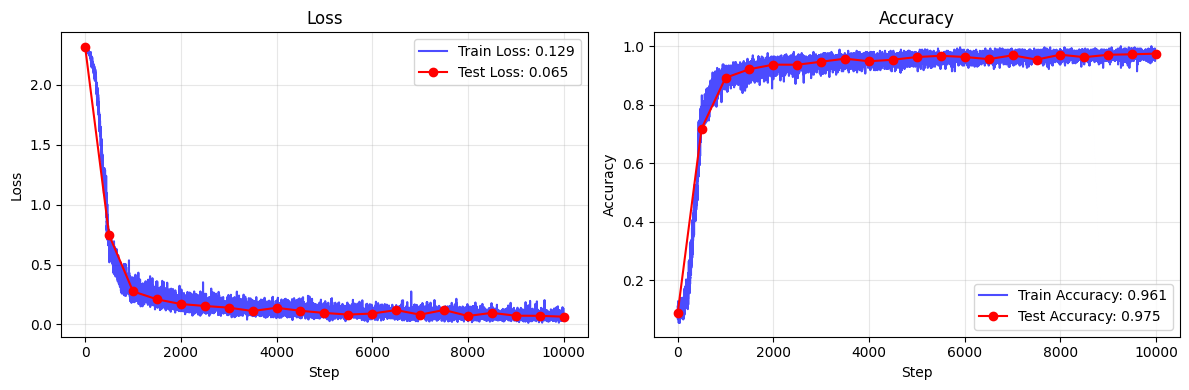

Train Loss: 0.129, Train Accuracy: 0.961 Test Loss: 0.065, Test Accuracy: 0.975: 100%|██████████| 10000/10000 [06:47<00:00, 24.53it/s]


In [14]:
model = train(model=model, trainloader=trainloader, testloader=testloader, iterations=10000, test_every=500, device=device)

## Visualizing CTM Dynamics

We define a function to create GIFs that show how the CTMs dynamics. These visualizations include:

- **Neuron activations** at each internal tick  
- **Attention patterns** across the input  
- **Predictions and certainty** at every step

In [ ]:
def make_gif(predictions, certainties, targets, pre_activations, post_activations, attention, inputs_to_model, filename):
    def reshape_attention_weights(attention, target_size=28):
        # The num_positions will not be a perfect square if the input size is not a perfect square. If d_input is not a perfect sqaure, interpolate
        T, B, num_heads, _, num_positions = attention.shape
        attention = torch.tensor(attention, dtype=torch.float32).mean(dim=2).squeeze(2)
        height = int(num_positions**0.5)
        while num_positions % height != 0: height -= 1
        width = num_positions // height
        attention = attention.view(T, B, height, width)
        return F.interpolate(attention, size=(target_size, target_size), mode='bilinear', align_corners=False)

    batch_index = 0
    n_neurons_to_visualise = 16
    figscale = 0.28
    n_steps = len(pre_activations)
    heCTMap_cmap = sns.color_palette("viridis", as_cmap=True)
    frames = []

    attention = reshape_attention_weights(attention)

    these_pre_acts = pre_activations[:, batch_index, :]
    these_post_acts = post_activations[:, batch_index, :]
    these_inputs = inputs_to_model[batch_index,:, :, :]
    these_attention_weights = attention[:, batch_index, :, :]
    these_predictions = predictions[batch_index, :, :]
    these_certainties = certainties[batch_index, :, :]
    this_target = targets[batch_index]

    class_labels = [str(i) for i in range(these_predictions.shape[0])]

    mosaic = [['img_data', 'img_data', 'attention', 'attention', 'probs', 'probs', 'probs', 'probs'] for _ in range(2)] + \
             [['img_data', 'img_data', 'attention', 'attention', 'probs', 'probs', 'probs', 'probs'] for _ in range(2)] + \
             [['certainty'] * 8] + \
             [[f'trace_{ti}'] * 8 for ti in range(n_neurons_to_visualise)]

    for stepi in tqdm(range(n_steps), desc="Processing steps", unit="step"):
        fig_gif, axes_gif = plt.subplot_mosaic(mosaic=mosaic, figsize=(31*figscale*8/4, 76*figscale))
        probs = softmax(these_predictions[:, stepi])
        colors = [('g' if i == this_target else 'b') for i in range(len(probs))]

        axes_gif['probs'].bar(np.arange(len(probs)), probs, color=colors, width=0.9, alpha=0.5)
        axes_gif['probs'].set_title('Probabilities')
        axes_gif['probs'].set_xticks(np.arange(len(probs)))
        axes_gif['probs'].set_xticklabels(class_labels, fontsize=24)
        axes_gif['probs'].set_yticks([])
        axes_gif['probs'].tick_params(left=False, bottom=False)
        axes_gif['probs'].set_ylim([0, 1])
        for spine in axes_gif['probs'].spines.values():
            spine.set_visible(False)
        axes_gif['probs'].tick_params(left=False, bottom=False)
        axes_gif['probs'].spines['top'].set_visible(False)
        axes_gif['probs'].spines['right'].set_visible(False)
        axes_gif['probs'].spines['left'].set_visible(False)
        axes_gif['probs'].spines['bottom'].set_visible(False)

        # Certainty
        axes_gif['certainty'].plot(np.arange(n_steps), these_certainties[1], 'k-', linewidth=2)
        axes_gif['certainty'].set_xlim([0, n_steps-1])
        axes_gif['certainty'].axvline(x=stepi, color='black', linewidth=1, alpha=0.5)
        axes_gif['certainty'].set_xticklabels([])
        axes_gif['certainty'].set_yticklabels([])
        axes_gif['certainty'].grid(False)
        for spine in axes_gif['certainty'].spines.values():
            spine.set_visible(False)

        # Neuron Traces
        for neuroni in range(n_neurons_to_visualise):
            ax = axes_gif[f'trace_{neuroni}']
            pre_activation = these_pre_acts[:, neuroni]
            post_activation = these_post_acts[:, neuroni]
            ax_pre = ax.twinx()

            ax_pre.plot(np.arange(n_steps), pre_activation, color='grey', linestyle='--', linewidth=1, alpha=0.4)
            color = 'blue' if neuroni % 2 else 'red'
            ax.plot(np.arange(n_steps), post_activation, color=color, linewidth=2, alpha=1.0)

            ax.set_xlim([0, n_steps-1])
            ax_pre.set_xlim([0, n_steps-1])
            ax.set_ylim([np.min(post_activation), np.max(post_activation)])
            ax_pre.set_ylim([np.min(pre_activation), np.max(pre_activation)])

            ax.axvline(x=stepi, color='black', linewidth=1, alpha=0.5)
            ax.set_xticklabels([])
            ax.set_yticklabels([])
            ax.grid(False)
            ax_pre.set_xticklabels([])
            ax_pre.set_yticklabels([])
            ax_pre.grid(False)

            for spine in ax.spines.values():
                spine.set_visible(False)
            for spine in ax_pre.spines.values():
                spine.set_visible(False)

        # Input image
        this_image = these_inputs[0]
        this_image = (this_image - this_image.min()) / (this_image.max() - this_image.min() + 1e-8)
        axes_gif['img_data'].set_title('Input Image')
        axes_gif['img_data'].imshow(this_image, cmap='binary', vmin=0, vmax=1)
        axes_gif['img_data'].axis('off')

        # Attention
        this_input_gate = these_attention_weights[stepi]
        gate_min, gate_max = np.nanmin(this_input_gate), np.nanmax(this_input_gate)
        if not np.isclose(gate_min, gate_max):
            normalized_gate = (this_input_gate - gate_min) / (gate_max - gate_min + 1e-8)
        else:
            normalized_gate = np.zeros_like(this_input_gate)
        attention_weights_heCTMap = heCTMap_cmap(normalized_gate)[:,:,:3]

        axes_gif['attention'].imshow(attention_weights_heCTMap, vmin=0, vmax=1)
        axes_gif['attention'].axis('off')
        axes_gif['attention'].set_title('Attention')

        fig_gif.tight_layout()
        canvas = fig_gif.canvas
        canvas.draw()
        image_numpy = np.frombuffer(canvas.buffer_rgba(), dtype='uint8')
        image_numpy = image_numpy.reshape(*reversed(canvas.get_width_height()), 4)[:, :, :3]
        frames.append(image_numpy)
        plt.close(fig_gif)


    mediapy.show_video(frames, width=400, codec="gif")
    imageio.mimsave(filename, frames, fps=5, loop=100)

The top row of the gif shows the input image, the attention weights and the models predictions.

The second plot, in black, shows the models certainty over time.

The red and blue lines correspond to the post-activations of different neurons, with the corresponding pre-activation shown in gray.

""

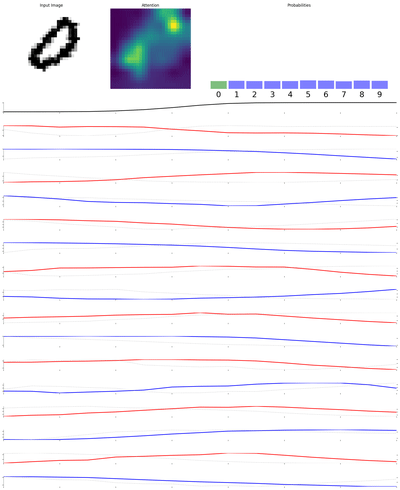

In [43]:
logdir = f"mnist_logs"
if not os.path.exists(logdir):
    os.makedirs(logdir)

model.eval()
with torch.inference_mode():
    inputs, targets = next(iter(testloader))
    inputs = inputs.to(device)

    predictions, certainties, (synch_out_tracking, synch_action_tracking), \
    pre_activations_tracking, post_activations_tracking, attention = model(inputs, track=True)

    make_gif(
        predictions.detach().cpu().numpy(),
        certainties.detach().cpu().numpy(),
        targets.detach().cpu().numpy(),
        pre_activations_tracking,
        post_activations_tracking,
        attention,
        inputs.detach().cpu().numpy(),
        f"{logdir}/prediction.gif"
    )